# European Employment Analysis (2015–2024)


## Research Questions

This analysis aims to explore the European labor market between 2015 and 2024.  
The main questions investigated in this project are:

1. How has the employment rate in Europe changed over time?
2. Which European countries have the highest and lowest employment rates?
3. Are there differences in employment rates between men and women?
4. How do employment rates vary across age groups?
5. Which countries improved their employment rates the most between 2015 and 2024?

In [1085]:
## 1. Data Loading
import pandas as pd

df = pd.read_csv("european_employment_unemployment_rates_2015_2024.csv")

## 2. Initial Data Exploration
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2450 entries, 0 to 2449
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SEX     2450 non-null   object 
 1   AGE     2450 non-null   object 
 2   ISO     2450 non-null   object 
 3   2015    2177 non-null   float64
 4   2016    2159 non-null   float64
 5   2017    2137 non-null   float64
 6   2018    2135 non-null   float64
 7   2019    2120 non-null   float64
 8   2020    2148 non-null   float64
 9   2021    2156 non-null   object 
 10  2022    2126 non-null   object 
 11  2023    2100 non-null   object 
 12  2024    2118 non-null   object 
dtypes: float64(6), object(7)
memory usage: 249.0+ KB


,2015,2016,2017,2018,2019,2020
count,2177.000000,2159.000000,2137.000000,2135.000000,2120.000000,2148.000000
mean,11.127331,10.236174,9.184043,8.196956,7.626698,8.373231
std,8.866571,8.203046,7.603100,7.099833,6.504433,6.872292
min,0.800000,0.900000,0.900000,0.900000,0.900000,1.100000
25%,5.600000,5.100000,4.600000,4.000000,3.600000,4.300000
50%,8.200000,7.600000,6.800000,5.800000,5.400000,6.100000
75%,13.200000,12.000000,10.700000,9.400000,9.200000,9.900000
max,70.700000,61.600000,65.200000,63.200000,52.900000,61.000000


In [1086]:

df.isnull().sum()


,0
SEX,0
AGE,0
ISO,0
2015,273
2016,291
2017,313
2018,315
2019,330
2020,302
2021,294


In [1087]:
## 3. Data Transformation
df_long = df.melt(
    id_vars=["ISO", "SEX", "AGE"],
    var_name="year",
    value_name="employment_rate"
)

In [1088]:
df_long.head()

,ISO,SEX,AGE,year,employment_rate
0,AT,F,15-19,2015,11.7
1,BA,F,15-19,2015,NaN
2,BE,F,15-19,2015,28.2
3,BG,F,15-19,2015,NaN
4,CH,F,15-19,2015,9.7


In [1089]:
## 4. Data Cleaning
df_long = df_long.dropna()

In [1090]:
df_long.isnull().sum()

,0
ISO,0
SEX,0
AGE,0
year,0
employment_rate,0


In [1091]:
df_long.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21376 entries, 0 to 24499
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ISO              21376 non-null  object
 1   SEX              21376 non-null  object
 2   AGE              21376 non-null  object
 3   year             21376 non-null  object
 4   employment_rate  21376 non-null  object
dtypes: object(5)
memory usage: 1002.0+ KB


In [1092]:
df_long["year"] = df_long["year"].astype(int)

In [1093]:
df_long["employment_rate"] = pd.to_numeric(df_long["employment_rate"], errors="coerce")

In [1094]:
df_long = df_long.dropna()

In [1095]:
df_long.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21363 entries, 0 to 24499
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ISO              21363 non-null  object 
 1   SEX              21363 non-null  object 
 2   AGE              21363 non-null  object 
 3   year             21363 non-null  int64  
 4   employment_rate  21363 non-null  float64
dtypes: float64(1), int64(1), object(3)
memory usage: 1001.4+ KB


In [1096]:
## 5. Employment Trends Over Time
df_long.groupby("year")["employment_rate"].mean()

,employment_rate
year,
2015,11.127331
2016,10.236174
2017,9.184043
2018,8.196956
2019,7.626698
2020,8.373231
2021,8.323734
2022,7.306645
2023,7.140629


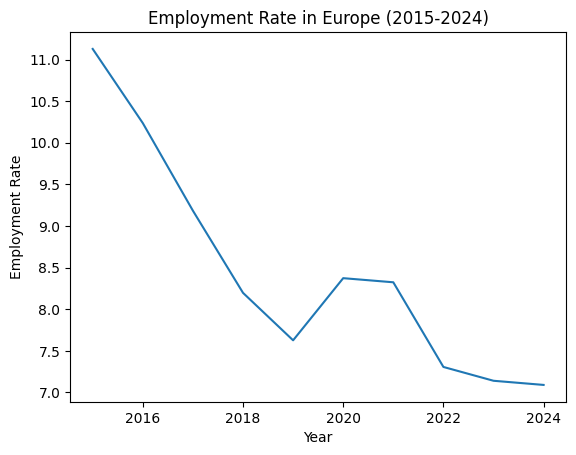

In [1097]:
### Employment Rate Trend Visualization
import matplotlib.pyplot as plt

trend = df_long.groupby("year")["employment_rate"].mean()

trend.plot()
plt.title("Employment Rate in Europe (2015-2024)")
plt.xlabel("Year")
plt.ylabel("Employment Rate")
plt.show()

In [1098]:
df_long["ISO"].nunique()

35

In [1099]:
df_long["ISO"].unique()

array(['AT', 'BE', 'CH', 'CY', 'CZ', 'DE', 'DK', 'GR', 'ES', 'FI', 'FR',
       'HR', 'HU', 'IE', 'IS', 'IT', 'MK', 'MT', 'NL', 'NO', 'PL', 'PT',
       'RO', 'RS', 'SE', 'SI', 'SK', 'TR', 'BG', 'EE', 'LT', 'LU', 'LV',
       'ME', 'BA'], dtype=object)

In [1100]:
yearly_avg = df_long.groupby("year")["employment_rate"].mean()

yearly_avg

,employment_rate
year,
2015,11.127331
2016,10.236174
2017,9.184043
2018,8.196956
2019,7.626698
2020,8.373231
2021,8.323734
2022,7.306645
2023,7.140629


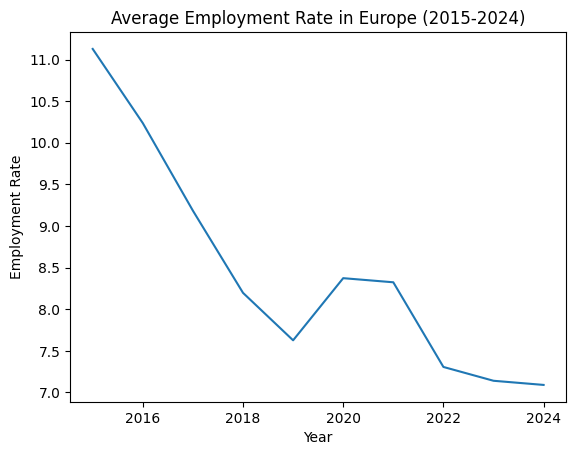

In [1101]:
import matplotlib.pyplot as plt

yearly_avg.plot()

plt.title("Average Employment Rate in Europe (2015-2024)")
plt.xlabel("Year")
plt.ylabel("Employment Rate")
plt.show()

In [1102]:
country_avg = df_long.groupby("ISO")["employment_rate"].mean().sort_values(ascending=False)

country_avg.head(10)

,employment_rate
ISO,
MK,19.392790
GR,18.782353
ME,17.262393
ES,16.915735
BA,16.781323
RS,13.286769
IT,11.405147
TR,10.442775
HR,10.142476


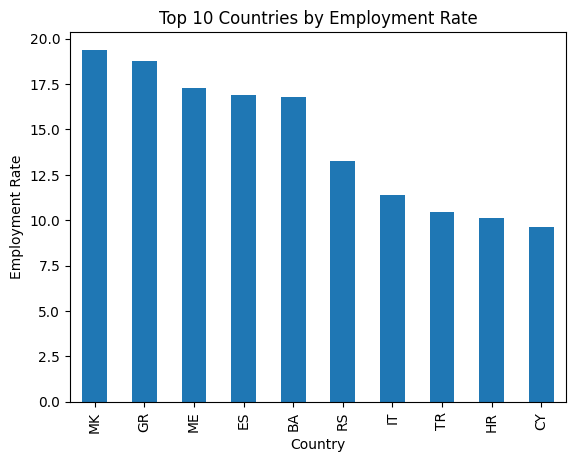

In [1103]:
## 6. Employment Rate by Country
top10 = country_avg.head(10)

top10.plot(kind="bar")

plt.title("Top 10 Countries by Employment Rate")
plt.xlabel("Country")
plt.ylabel("Employment Rate")
plt.show()

In [1104]:
## 7. Employment Rate by Gender
df_long.groupby("SEX")["employment_rate"].mean()

,employment_rate
SEX,
F,8.688864
M,8.260631


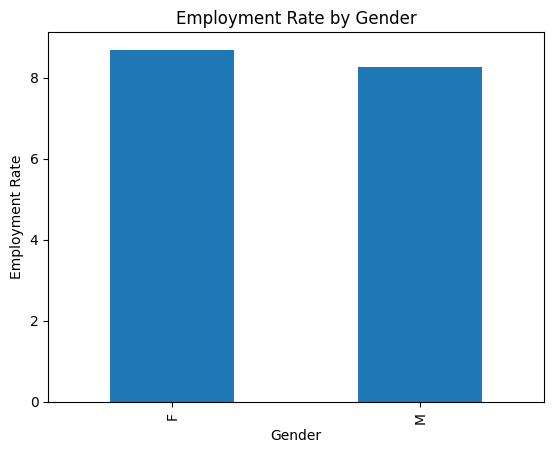

In [1105]:
sex_avg = df_long.groupby("SEX")["employment_rate"].mean()

sex_avg.plot(kind="bar")

plt.title("Employment Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Employment Rate")
plt.show()

In [1106]:
## 8. Employment Rate by Age Group
age_avg = df_long.groupby("AGE")["employment_rate"].mean().sort_values()

age_avg

,employment_rate
AGE,
70-74,2.522727
65-74,4.055422
65-69,4.724638
50-74,5.577444
40-64,5.822941
50-64,5.832331
40-59,5.855817
55-64,5.978673
50-59,5.996610


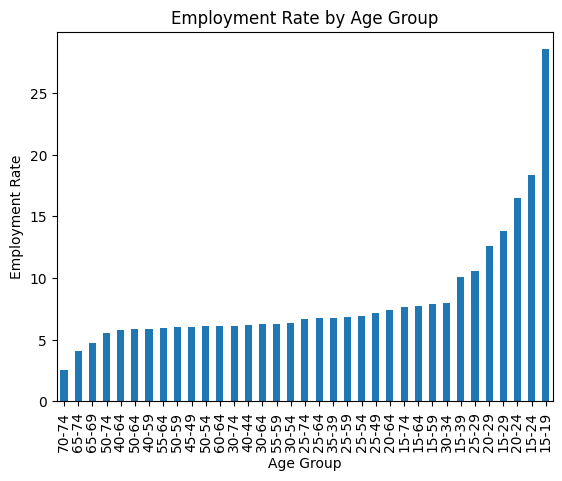

In [1107]:
age_avg.plot(kind="bar")

plt.title("Employment Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Employment Rate")
plt.show()

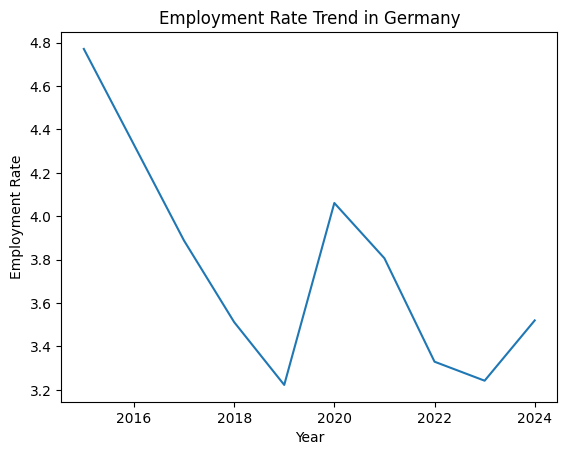

In [1108]:
germany = df_long[df_long["ISO"] == "DE"]

germany.groupby("year")["employment_rate"].mean().plot()

plt.title("Employment Rate Trend in Germany")
plt.xlabel("Year")
plt.ylabel("Employment Rate")
plt.show()

In [1109]:
yearly_avg = df_long.groupby("year")["employment_rate"].mean()
yearly_avg

,employment_rate
year,
2015,11.127331
2016,10.236174
2017,9.184043
2018,8.196956
2019,7.626698
2020,8.373231
2021,8.323734
2022,7.306645
2023,7.140629


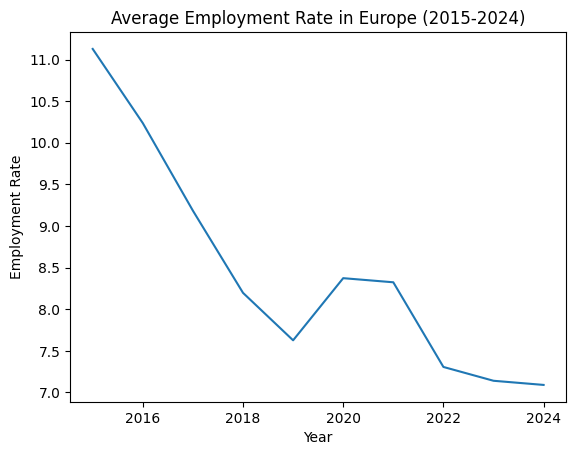

In [1110]:
import matplotlib.pyplot as plt

yearly_avg.plot()

plt.title("Average Employment Rate in Europe (2015-2024)")
plt.xlabel("Year")
plt.ylabel("Employment Rate")
plt.show()

In [1111]:
country_avg = df_long.groupby("ISO")["employment_rate"].mean().sort_values(ascending=False)

country_avg.head(10)

,employment_rate
ISO,
MK,19.392790
GR,18.782353
ME,17.262393
ES,16.915735
BA,16.781323
RS,13.286769
IT,11.405147
TR,10.442775
HR,10.142476


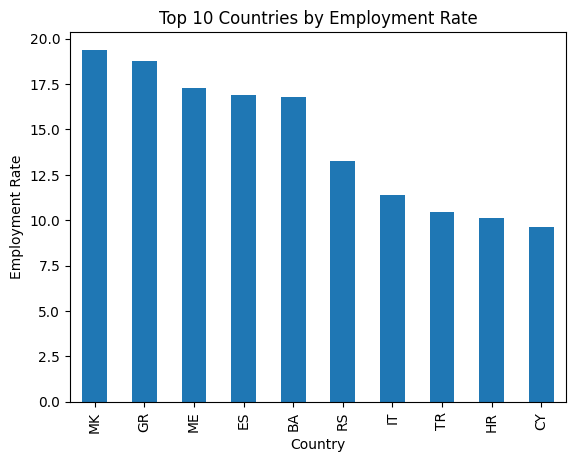

In [1112]:
top10 = country_avg.head(10)

top10.plot(kind="bar")

plt.title("Top 10 Countries by Employment Rate")
plt.xlabel("Country")
plt.ylabel("Employment Rate")
plt.show()

In [1113]:
df_long.groupby("SEX")["employment_rate"].mean()

,employment_rate
SEX,
F,8.688864
M,8.260631


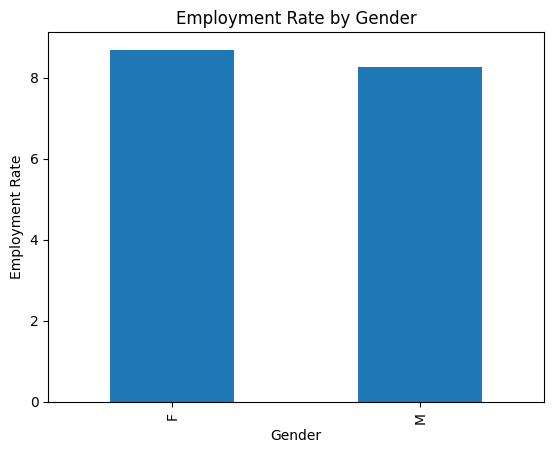

In [1114]:
sex_avg = df_long.groupby("SEX")["employment_rate"].mean()

sex_avg.plot(kind="bar")

plt.title("Employment Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Employment Rate")
plt.show()

In [1115]:
age_avg = df_long.groupby("AGE")["employment_rate"].mean().sort_values()

age_avg

,employment_rate
AGE,
70-74,2.522727
65-74,4.055422
65-69,4.724638
50-74,5.577444
40-64,5.822941
50-64,5.832331
40-59,5.855817
55-64,5.978673
50-59,5.996610


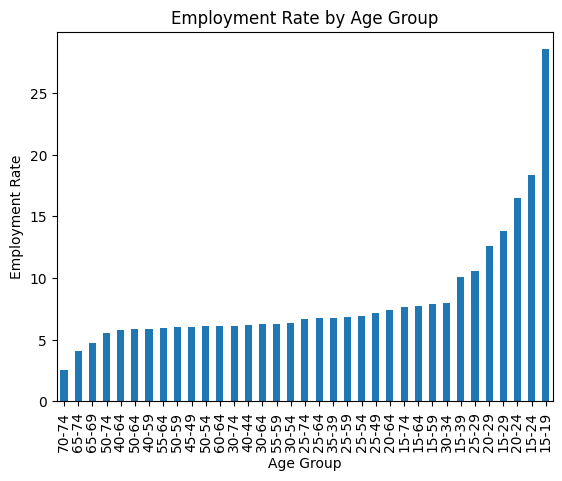

In [1116]:
age_avg.plot(kind="bar")

plt.title("Employment Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Employment Rate")
plt.show()

In [1117]:
import seaborn as sns
import matplotlib.pyplot as plt

In [1118]:
pivot_table = df_long.pivot_table(
    values="employment_rate",
    index="ISO",
    columns="year"
)

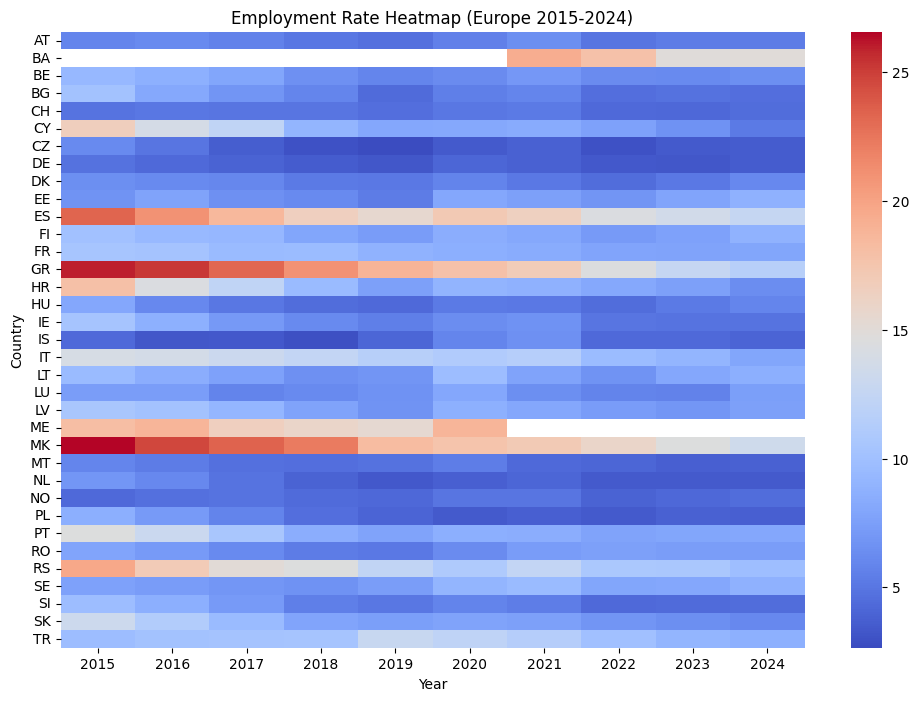

In [1119]:
## 9. Employment Rate Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(pivot_table, cmap="coolwarm")

plt.title("Employment Rate Heatmap (Europe 2015-2024)")
plt.xlabel("Year")
plt.ylabel("Country")

plt.show()

## Key Insights

- Employment rates in Europe generally increased between 2015 and 2024.
- Northern and Western European countries tend to have higher employment rates.
- Employment levels are generally higher among men than women.
- Younger age groups show significantly lower employment rates.